In [147]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy
import os
import networkx as nx
import torch
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [148]:
def build_gene_subgraph(matrix, gene_names, gene, top_targets=8):
    """
    Construit un DiGraph centré sur `gene` montrant ses top cibles.
    Retourne (G, max_intensity).
    """
    gene_names = list(gene_names)
    if gene not in gene_names:
        return None, 1.0

    idx = gene_names.index(gene)
    series = pd.Series(matrix[idx, :], index=gene_names)
    series = series.drop(gene, errors='ignore')

    top_idx = series.abs().nlargest(top_targets).index
    max_intensity = series.abs().max() or 1.0

    G = nx.DiGraph()
    for tgt in top_idx:
        w = series[tgt]
        if w != 0:
            G.add_edge(gene, tgt, weight=float(w))
    return G, float(max_intensity)

def draw_gene_subgraph(ax, G, gene, max_intensity):
    """
    Dessine le sous-graphe sur un Axes matplotlib.
    Polices et nœuds réduits (v2).
    """
    if G is None or G.number_of_edges() == 0:
        ax.text(0.5, 0.5, f"{gene}\n(no GRN data)", ha='center', va='center',
                transform=ax.transAxes, fontsize=6, color='gray')
        ax.axis('off')
        return

    pos = nx.spring_layout(G, seed=42, pos={gene: (0.0, 0.0)}, fixed=[gene])

    # Taille des nœuds réduite, police réduite
    node_colors = ['#4C9BE8' if n == gene else '#E8E8E8' for n in G.nodes]
    node_sizes  = [800 if n == gene else 600 for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=5.5, ax=ax)
    ax.margins(0.15)  # empêche les nœuds d'être coupés aux bords

    edges_pos = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    edges_neg = [(u, v, d['weight']) for u, v, d in G.edges(data=True) if d['weight'] < 0]

    width_scale = 3.0
    wp = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_pos]
    wn = [abs(w) / max_intensity * width_scale for (_, _, w) in edges_neg]

    kw_pos = dict(arrows=True, arrowsize=8, ax=ax, connectionstyle='arc3,rad=0.1', min_target_margin=15)
    kw_neg = dict(
        ax=ax, connectionstyle='arc3,rad=0.1',
        arrows=True,
        arrowstyle='-[,widthB=0.8,lengthB=0.0',  # flat T-bar = inhibition
        min_target_margin=15,
    )
    if edges_pos:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for u, v, _ in edges_pos],
                               edge_color='#2ECC71', width=wp, **kw_pos)
    if edges_neg:
        nx.draw_networkx_edges(G, pos,
                               edgelist=[(u, v) for u, v, _ in edges_neg],
                               edge_color='#E74C3C', width=wn, **kw_neg)

    ax.set_title(f"Targets of {gene}", fontsize=6.5, fontweight='bold', pad=2)
    ax.axis('off')


In [173]:
def draw_full_grn(ax, matrix, gene_names, top_frac=0.02):
    """
    Draws the full GRN keeping interacting genes spatially close.

    A single force-directed (spring) layout is used on the full graph so that
    strongly connected genes are pulled together naturally, without imposing
    explicit community clusters.

    Parameters
    ----------
    top_frac : float
        Keep only the top fraction of edges by absolute weight (default 5 %).
    """
    gene_names = list(gene_names)
    n = len(gene_names)

    G = nx.DiGraph()
    G.add_nodes_from(gene_names)

    all_abs = np.abs(matrix)
    flat = all_abs.flatten()
    threshold = np.percentile(flat[flat > 0], (1 - top_frac) * 100)
    max_w = flat.max() or 1.0

    for i in range(n):
        for j in range(n):
            if i != j and all_abs[i, j] >= threshold:
                G.add_edge(gene_names[i], gene_names[j], weight=float(matrix[i, j]))

    # ── Layout: single spring layout — connected nodes attract each other ──
    # Use absolute weight as the spring strength so stronger regulatory pairs
    # end up closer together.
    G_und = G.to_undirected()
    for u, v in G_und.edges():
        # average absolute weight of all directed edges between u and v
        weights = [abs(G[a][b]['weight']) for a, b in [(u, v), (v, u)] if G.has_edge(a, b)]
        G_und[u][v]['weight'] = float(np.mean(weights))

    # Larger k pushes nodes further apart; more iterations improves convergence
    pos = nx.spring_layout(G_und, weight='weight', seed=42,
                           k=6.0 / (n ** 0.5), iterations=200)

    # ── Post-process: repulsion to separate overlapping nodes ─────────────
    min_dist = 0.12  # minimum separation in layout units
    nodes_list = list(pos.keys())
    rng = np.random.default_rng(42)
    for _ in range(100):
        moved = False
        for i in range(len(nodes_list)):
            for j in range(i + 1, len(nodes_list)):
                ni, nj = nodes_list[i], nodes_list[j]
                delta = pos[ni] - pos[nj]
                dist = np.linalg.norm(delta)
                if dist < min_dist:
                    if dist > 1e-9:
                        push = (min_dist - dist) / 2.0 * delta / dist
                    else:
                        angle = rng.uniform(0, 2 * np.pi)
                        push = min_dist / 2.0 * np.array([np.cos(angle), np.sin(angle)])
                    pos[ni] = pos[ni] + push
                    pos[nj] = pos[nj] - push
                    moved = True
        if not moved:
            break

    # ── Post-process: pull isolated nodes (no edges) closer to the cluster ──
    isolated = [node for node in G.nodes if G.degree(node) == 0]
    if isolated:
        connected_positions = np.array([pos[node] for node in G.nodes if G.degree(node) > 0])
        if len(connected_positions) > 0:
            center = connected_positions.mean(axis=0)
            dists = np.linalg.norm(connected_positions - center, axis=1)
            radius = dists.max() if dists.max() > 0 else 1.0
            angle_step = 2 * np.pi / max(len(isolated), 1)
            for i, node in enumerate(isolated):
                angle = i * angle_step
                pos[node] = center + (radius + 0.15) * np.array([np.cos(angle), np.sin(angle)])

    # ── Node appearance: colour by regulatory power ───────────────────────
    reg_power = all_abs.sum(axis=1)
    max_power = reg_power.max() or 1.0
    node_power = np.array([
        float(reg_power[gene_names.index(node)]) / max_power
        for node in G.nodes
    ])

    cmap = plt.cm.get_cmap('YlOrRd')
    node_colors = [cmap(p) for p in node_power]
    node_sizes = 100

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=3, ax=ax)
    ax.margins(0.12)

    # ── Edge appearance ───────────────────────────────────────────────────
    edges_pos = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
    edges_neg = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 0]

    def widths(edgelist):
        return [abs(G[u][v]['weight']) / max_w * 2.5 for u, v in edgelist]

    kw = dict(arrows=True, arrowsize=7, connectionstyle='arc3,rad=0.12',
              min_target_margin=12, ax=ax)

    if edges_pos:
        nx.draw_networkx_edges(G, pos, edgelist=edges_pos,
                               edge_color='#2ECC71', width=widths(edges_pos),
                               alpha=0.6, **kw)
    if edges_neg:
        nx.draw_networkx_edges(G, pos, edgelist=edges_neg,
                               edge_color='#E74C3C', width=widths(edges_neg),
                               alpha=0.6, **kw)

    # ── Legend ────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], color='#2ECC71', linewidth=1.5, label='Activation'),
        Line2D([0], [0], color='#E74C3C', linewidth=1.5, label='Inhibition'),
    ]
    ax.legend(handles=legend_elements, fontsize=5, loc='lower right',
              framealpha=0.7, borderpad=0.4)
    ax.set_title(
        f'GRN (top {int(top_frac * 100)}% edges)',
        fontsize=6.5, fontweight='bold', pad=2
    )
    ax.axis('off')


In [174]:
def load_grn_matrix(p):
    """Charge la matrice GRN inférée (inter_simul.npy) et renvoie (matrix, gene_names)."""
    # data_full.h5ad si disponible, sinon data_train.h5ad
    full_path = os.path.join(p, 'Data', 'data_full.h5ad')
    train_path = os.path.join(p, 'Data', 'data_train.h5ad')
    adata = sc.read_h5ad(full_path if os.path.exists(full_path) else train_path)
    genes = list(adata.var_names)
    grn_path = os.path.join(p, 'cardamom', 'inter_simul.npy')
    grn_mat = np.load(grn_path)[1:, 1:]
    matrix = grn_mat[:, :, 0] if grn_mat.ndim == 3 else grn_mat
    return matrix, genes

In [175]:
def figure_sup1_3(datapath, figname = 'figure_sup1_3.pdf'):
    matrix, gene_names = load_grn_matrix(datapath)

    fig = plt.figure(figsize=(8.27, 11.69))
    gs   = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[2, 1],
                            hspace=0.1, wspace=0.28)
    gs01 = gs[0, 0].subgridspec(2, 1, hspace=0.1, wspace=0.2)
    gs02 = gs[1, 0].subgridspec(2, 2, hspace=0.1, wspace=0.2)
    axes = (
    [fig.add_subplot(gs01[r, c]) for r in range(2) for c in range(1)] +
    [fig.add_subplot(gs02[r, c]) for r in range(2) for c in range(2)] )
    for ax, label in zip(axes, "ABCDEF"):
        ax.text(-0.08, 1.05, label, transform=ax.transAxes,
                ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)

    # Full GRN circular network in 1st plot of gs01
    draw_full_grn(axes[0], matrix, gene_names)

    # Heatmap of inter in 2nd plot of gs01
    extremum = np.max(np.abs(matrix))
    im = axes[1].imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=-extremum, vmax=extremum)
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)
    axes[1].set_title('GRN')

    # Top 4 genes by regulatory power (row-wise sum of absolute weights)
    reg_power = np.abs(matrix).sum(axis=1)
    top4_idx = np.argsort(reg_power)[::-1][:4]
    top4_genes = [gene_names[i] for i in top4_idx]

    for ax, gene in zip(axes[2:], top4_genes):
        G, max_intensity = build_gene_subgraph(matrix, gene_names, gene)
        draw_gene_subgraph(ax, G, gene, max_intensity)

    plt.savefig(figname, dpi=600, bbox_inches='tight')
    plt.show()


In [176]:
path_schiebinger = '../../../../data/Datas_exp/Schiebinger'

/tmp/ipykernel_41526/2852642112.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


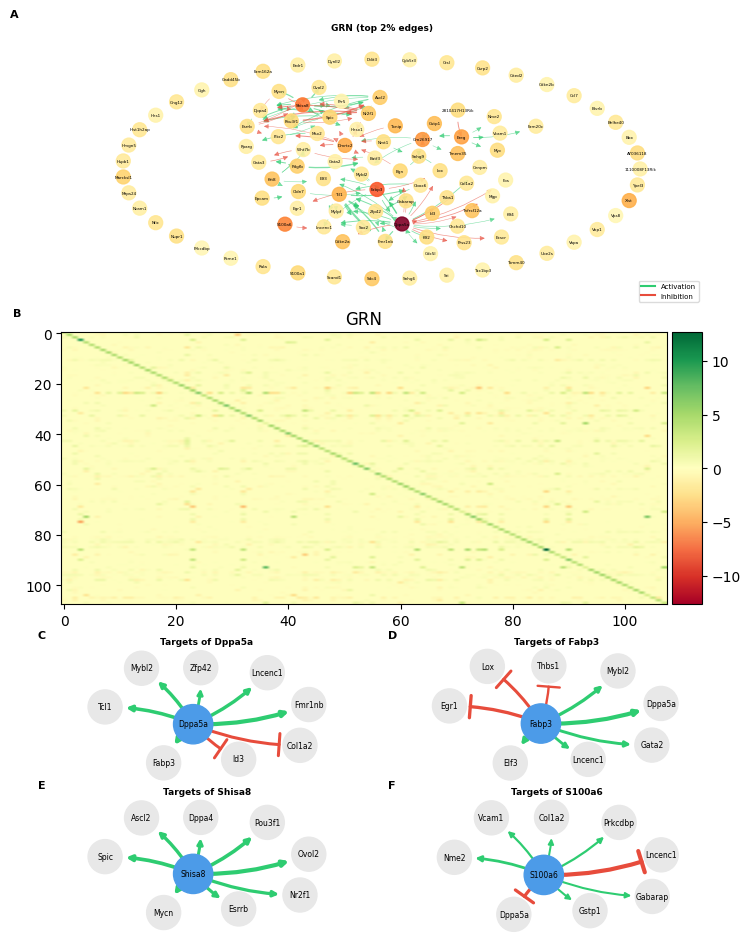

In [177]:
figure_sup1_3(path_schiebinger, figname='figure_sup3.pdf')

In [58]:
inter_schiebinger = np.load(os.path.join(path_schiebinger, 'inter.npy'))

In [18]:
inter_schiebinger.shape

(109, 109, 1)